# Домашнее задание: Глубокое обучение на реальных данных

В этом задании вы будете работать с датасетом Oxford-IIIT Pet — набором изображений 37 пород кошек и собак. Ваша задача: пройти полный цикл разработки модели классификации, применить все изученные методы регуляризации и проанализировать результаты.

**Цели:**
1. Загрузить и визуализировать реальные данные.
2. Построить baseline-модель и диагностировать переобучение.
3. Применить регуляризацию (L2, Dropout, BatchNorm, аугментацию).
4. Сравнить кривые обучения и сделать выводы.

Начнём с установки необходимых библиотек.

Импортируйте все необходимые библиотеки: PyTorch, torchvision, matplotlib, numpy, tqdm.
Также определите устройство (GPU, если доступно).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm



In [2]:
torch.manual_seed(42)
np.random.seed(42)

Теперь мы используем датасет **Oxford-IIIT Pet** — 37 пород кошек и собак. Датасет доступен в `torchvision.datasets.OxfordIIITPet`.

1. Создайте трансформацию для **обучения** (только ToTensor и нормализация).
2. Создайте трансформацию для **теста** (аналогично).
3. Загрузите тренировочный набор с `split='trainval'` и тестовый с `split='test'`.
4. Выведите количество классов и примеров.

Для нормализации используем стандартные для ImageNet: `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406,), (0.229, 0.224, 0.225,))
])

data_train = datasets.OxfordIIITPet('./data',split='trainval',transform=transform,download=True)
data_test = datasets.OxfordIIITPet('./data',split='test',transform=transform,download=True)

In [4]:
def check_classes(data):
    counts = {}
    for _, label in data:
        class_name = data.classes[label]
        counts[class_name] = counts.get(class_name, 0) + 1

    return counts

train_counts = check_classes(data_train)
test_counts = check_classes(data_test)

In [5]:
print('TRAIN')
for name, count in train_counts.items():
    print(name, count)

print('*'*100)

print('TEST')
for name, count in test_counts.items():
    print(name, count)

TRAIN
Abyssinian 100
American Bulldog 100
American Pit Bull Terrier 100
Basset Hound 100
Beagle 100
Bengal 100
Birman 100
Bombay 96
Boxer 100
British Shorthair 100
Chihuahua 100
Egyptian Mau 93
English Cocker Spaniel 96
English Setter 100
German Shorthaired 100
Great Pyrenees 100
Havanese 100
Japanese Chin 100
Keeshond 100
Leonberger 100
Maine Coon 100
Miniature Pinscher 100
Newfoundland 96
Persian 100
Pomeranian 100
Pug 100
Ragdoll 100
Russian Blue 100
Saint Bernard 100
Samoyed 100
Scottish Terrier 100
Shiba Inu 100
Siamese 99
Sphynx 100
Staffordshire Bull Terrier 100
Wheaten Terrier 100
Yorkshire Terrier 100
****************************************************************************************************
TEST
Abyssinian 98
American Bulldog 100
American Pit Bull Terrier 100
Basset Hound 100
Beagle 100
Bengal 100
Birman 100
Bombay 88
Boxer 99
British Shorthair 100
Chihuahua 100
Egyptian Mau 97
English Cocker Spaniel 100
English Setter 100
German Shorthaired 100
Great Pyrenees 100
Ha

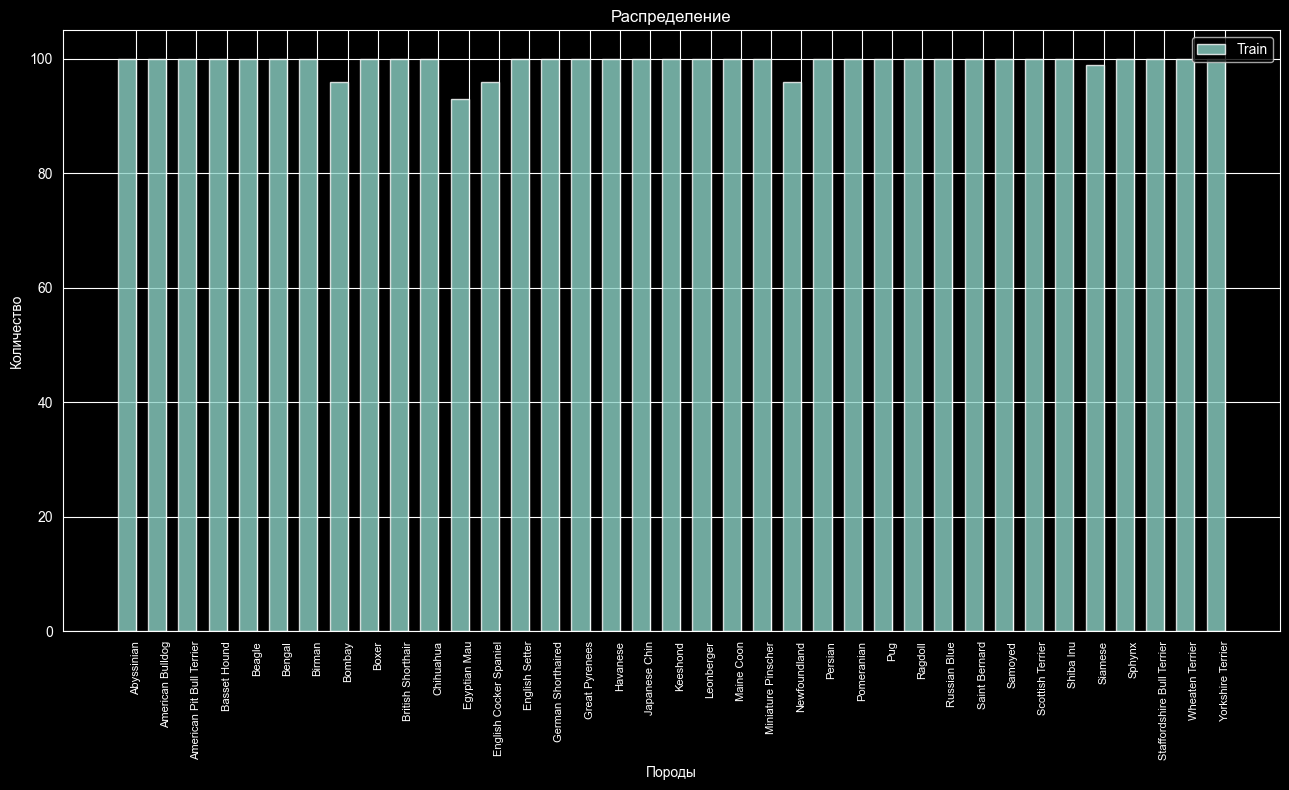

In [6]:
classes = list(train_counts.keys())
train_values = [train_counts[c] for c in classes]
test_values = [test_counts[c] for c in classes]

plt.figure(figsize=(13, 8))
x = range(len(classes))
width = 0.6
plt.bar([i - width/2 for i in x], train_values, width, label='Train', alpha=0.8)
plt.xlabel('Породы')
plt.ylabel('Количество')
plt.title('Распределение')
plt.xticks(x, classes, rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

Посмотрите, что за картинки мы будем классифицировать.

Напишите функцию, которая выводит сетку 3x3 случайных изображений из тренировочного набора с подписями классов. Используйте `matplotlib`. Не забудьте денормализовать картинки для правильного отображения.

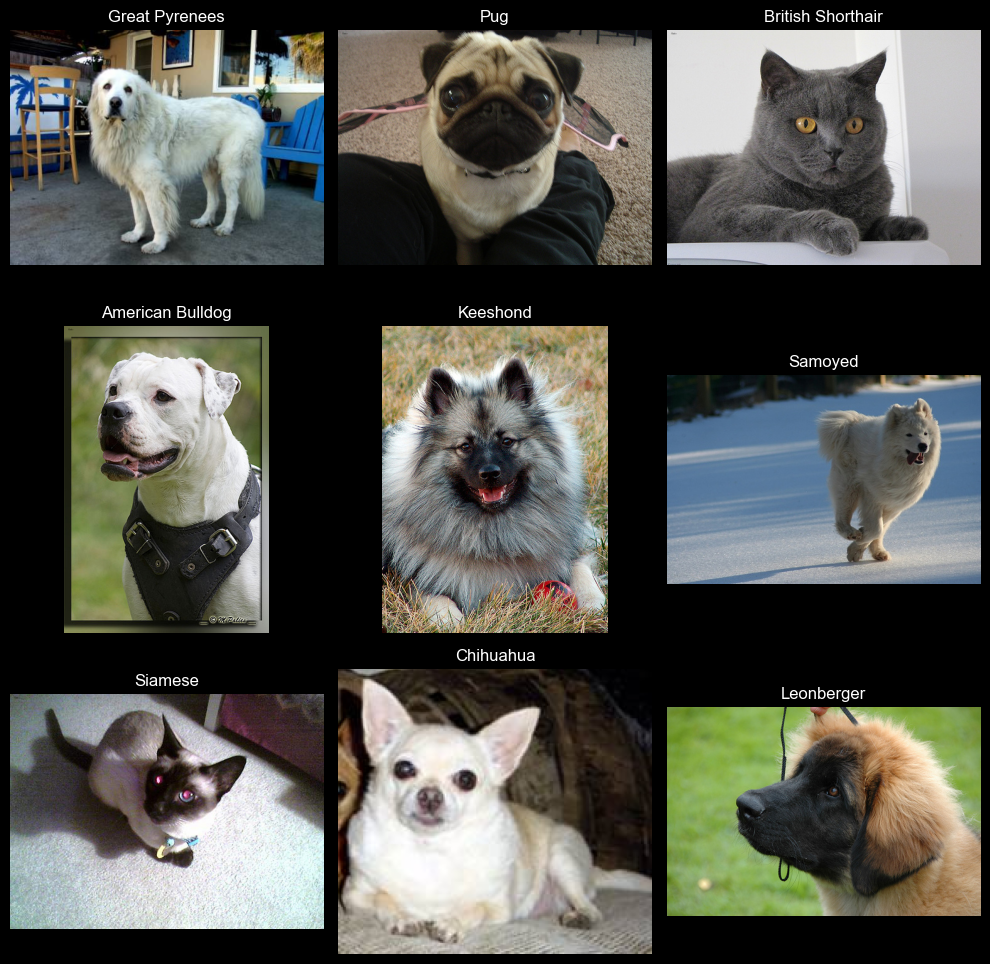

In [7]:
import random

def show_random_images(data,mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    for x in range(9):
        img,label = data[random.randint(0,len(data)-1)]
        img = img.permute(1, 2, 0)
        img = img * torch.tensor(std) + torch.tensor(mean)
        img = img.clamp(0, 1)
        axes[x].imshow(img)
        axes[x].set_title(data.classes[label])
        axes[x].axis('off')
    plt.tight_layout()
    plt.show()

show_random_images(data_train,)

Создайте загрузчики данных:
- `train_loader` с `batch_size=32` и `shuffle=True`.
- `test_loader` с `batch_size=32` и `shuffle=False`.

Мы будем использовать маленький размер батча, чтобы модель быстрее обновлялась и мы могли наблюдать динамику.

In [8]:
train_loader = DataLoader(data_train,batch_size=32,shuffle=True)
test_loader = DataLoader(data_test,batch_size=32,shuffle=False)

Создайте класс `SimpleCNN` со следующей архитектурой:
- Свёрточный слой: 3 канала → 32 канала, kernel=3, padding=1
- ReLU, MaxPool(2,2)
- Свёрточный слой: 32 → 64, kernel=3, padding=1
- ReLU, MaxPool(2,2)
- Свёрточный слой: 64 → 128, kernel=3, padding=1
- ReLU, MaxPool(2,2)
- Глобальный AvgPool (можно AdaptiveAvgPool2d(1))
- Полносвязный слой: 128 → 37 (количество классов)

Не забудьте, что после свёрток нужно выпрямить тензор перед полносвязным слоем.

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,kernel_size=3,padding=1)
        self.pool1 = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.pool2 = nn.MaxPool2d(2,2)

        self.conv3 = nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.pool3 = nn.MaxPool2d(2,2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(128,37)
        self.relu = nn.ReLU()

    def forward(self,x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

Напишите функцию `train_model`, которая:
- Принимает модель, загрузчики, число эпох, learning rate, weight decay (для L2), и флаг `use_clipping`.
- Использует `CrossEntropyLoss` и оптимизатор Adam.
- Для каждой эпохи вычисляет train loss, train accuracy, test loss, test accuracy.
- Если `use_clipping=True`, применяет gradient clipping с `max_norm=1.0`.
- Возвращает словарь с историей метрик.

Функция должна выводить прогресс по эпохам (можно использовать tqdm).

In [10]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.01, weight_decay=0, use_clipping=True, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr,weight_decay=weight_decay)

    train_losses, test_losses, train_accs, test_accs = [], [], [], []

    for epoch in tqdm(range(epochs), desc="Обучение"):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            y_pred = model(data)
            loss = criterion(y_pred, target)
            loss.backward()

            if use_clipping:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(y_pred, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()

        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                y_pred = model(data)
                loss = criterion(y_pred, target)

                test_loss += loss.item()
                _, predicted = torch.max(y_pred, 1)
                total_test += target.size(0)
                correct_test += (predicted == target).sum().item()

        train_losses.append(train_loss / len(train_loader))
        test_losses.append(test_loss / len(test_loader))
        train_accs.append(correct_train / total_train * 100)
        test_accs.append(correct_test / total_test * 100)

        print(f'Epoch {epoch+1:2d} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f}% | Test Loss: {test_losses[-1]:.4f} | Test Acc: {test_accs[-1]:.4f}%')
    return {
        'train_loss': train_losses,
        'test_loss': test_losses,
        'train_acc': train_accs,
        'test_acc': test_accs
    }

Обучите модель `SimpleCNN` без регуляризации (weight_decay=0, use_clipping=False) на 20 эпохах.

Сохраните историю в переменную `history_no_reg`.

Постройте два графика для эксперимента без регуляризации:
1. Train и Test Loss по эпохам.
2. Train и Test Accuracy по эпохам.

Есть ли признаки переобучения? На какой эпохе test loss перестаёт снижаться или начинает расти? Сделайте вывод.

Создайте модифицированную модель `RegularizedCNN`, которая добавляет:
- Dropout (p=0.5) после каждого свёрточного блока (после пула).
- Возможность включать Batch Normalisation после свёрточных слоёв (перед ReLU).

Добавьте параметры в `__init__`: `use_dropout=True, dropout_prob=0.5, use_batchnorm=True`. Классов по-прежнему 37.

Обучите модель `RegularizedCNN` с параметрами:
- `use_dropout=True, use_batchnorm=True`
- `weight_decay=1e-4` (в оптимизаторе)
- `use_clipping=False` (или True, поэкспериментируйте)

Сохраните историю в `history_reg`.

Постройте на одном графике:
- Test loss для модели без регуляризации и с регуляризацией.
- Test accuracy для обеих моделей.

Сделайте вывод: насколько регуляризация помогла? Уменьшился ли разрыв между train и test?

Теперь добавим аугментацию. Создайте новый набор трансформаций для тренировки:
- RandomResizedCrop(224)
- RandomHorizontalFlip(p=0.5)
- ColorJitter(brightness=0.2, contrast=0.2)
- ToTensor
- Нормализация

Загрузите Oxford-IIIT Pet заново с этой трансформацией (можно использовать тот же корень, данные уже скачаны).
Создайте новый загрузчик `train_loader_aug`.

Обучите модель `RegularizedCNN` на аугментированных данных с теми же гиперпараметрами (weight_decay=1e-4).
Сохраните историю в `history_aug`.

**Важно:** на тесте аугментация не применяется, используйте тот же `test_loader`, что и раньше.

Постройте финальный график, на котором будут Test Accuracy для трёх экспериментов:
1. Baseline без регуляризации.
2. С регуляризацией (L2+Dropout+BN).
3. С регуляризацией + аугментация.

Какой эксперимент показал лучший результат? Почему?

Напишите небольшой вывод (5-10 предложений) о том:
- Какие методы регуляризации оказались наиболее эффективными на этом датасете.
- Насколько аугментация улучшила результат.
- Что бы вы попробовали ещё для улучшения качества (например, изменение архитектуры, подбор гиперпараметров, предобученные модели).

Это задание без кода, просто текст.